In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Clean the data
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df.drop_duplicates()

In [4]:
# Create new useful features:
# - Revenue per transaction
# - Month (for time-based analysis)
# - Hour (for hourly behavior analysis)
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Hour'] = df['InvoiceDate'].dt.hour

In [5]:
# New Features:
# - Total revenue
# - Revenue over time (monthly)
# - Top products by quantity sold
# - Top customers by revenue
# - Revenue by country

total_revenue = df['Revenue'].sum()

monthly_revenue = df.groupby('Month')['Revenue'].sum()

top_products = (df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10))

top_customers = (df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10))

country_sales = (df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10))

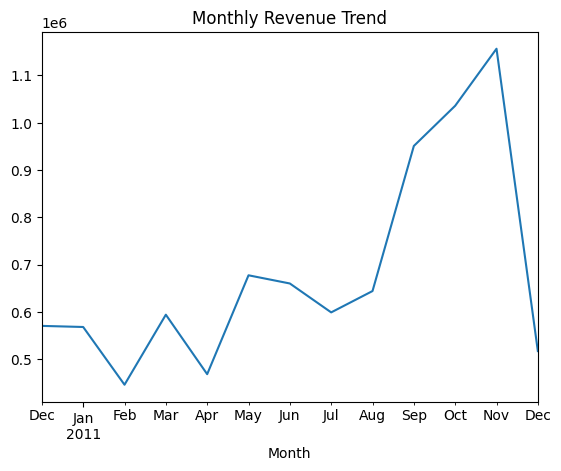

In [6]:
# Plot monthly revenue
plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.show()

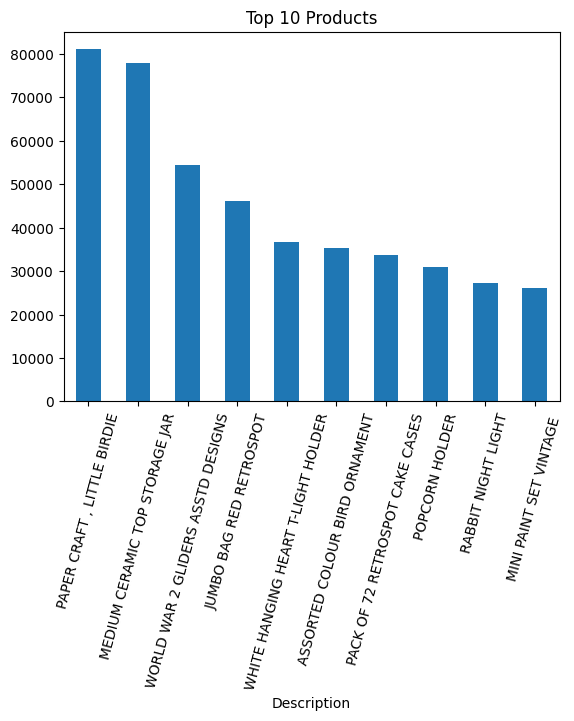

In [7]:
# Plot top 10 products
plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.xticks(rotation=75)
plt.show()

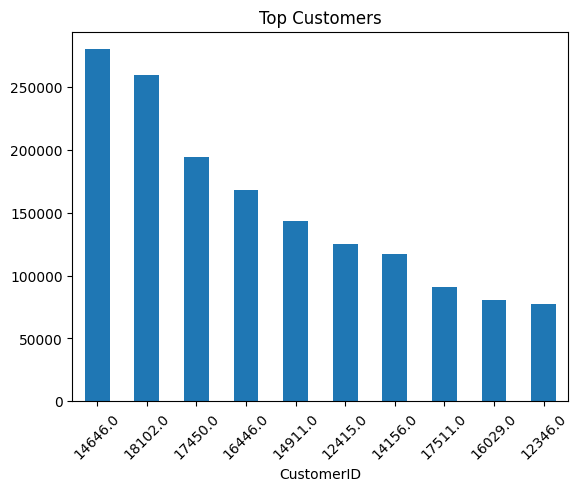

In [8]:
# Plot top customers
plt.figure()
top_customers.plot(kind='bar')
plt.title("Top Customers")
plt.xticks(rotation=45)
plt.show()

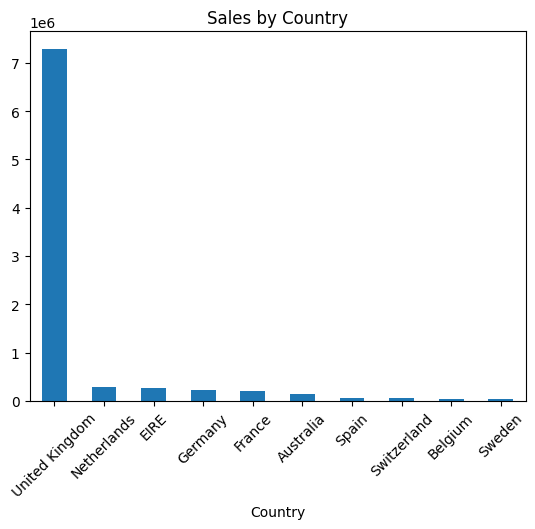

In [9]:
# Plot top countries by revenue
plt.figure()
country_sales.plot(kind='bar')
plt.title("Sales by Country")
plt.xticks(rotation=45)
plt.show()